# **Datos del Estudiante**

Nombre: Odilón Nolf Sánchez

CI: 4189076

# Clase 6 — Evaluación y Selección de Modelos
**Profesor:** Prof. Dr. Pástor E Pérez Estigarribia (adaptado)  
**Objetivo del notebook:** consolidar conceptos de evaluación (matrices, ROC/AUC), validación cruzada y búsqueda de hiperparámetros (Grid / Randomized), y practicar con demos y desafíos reproducibles en Colab.  
**Archivos generados:** figuras en `figures/`, resúmenes en `outputs/`.  


## Objetivos de aprendizaje
Al finalizar este notebook el estudiante podrá:
- Explicar y calcular métricas de clasificación: accuracy, precision, recall, F1 y AUC.
- Interpretar una matriz de confusión y una curva ROC.
- Aplicar validación cruzada (k‑fold, stratified) y entender su utilidad.
- Ejecutar GridSearchCV y RandomizedSearchCV; comparar cobertura, coste y resultados.
- Implementar y evaluar un StackingClassifier y un árbol ponderado para datos desbalanceados.
- Diseñar una estrategia práctica de búsqueda de hiperparámetros (incluyendo estrategia híbrida).


## **3 — Imports y configuración**

In [2]:
# Imports y configuración inicial
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')

from sklearn import datasets
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV, RandomizedSearchCV,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Crear carpetas de salida
os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Semilla reproducible
RND = 42
np.random.seed(RND)


# **BLOQUE A — Implementaciones demostrativas**

### Demo A — ROC con validación cruzada
Objetivo: visualizar la curva ROC media y su variabilidad usando k‑fold CV; calcular AUC por fold y guardar figura `figures/roc_crossval.png`.


## **A.1 — Demo A: código**

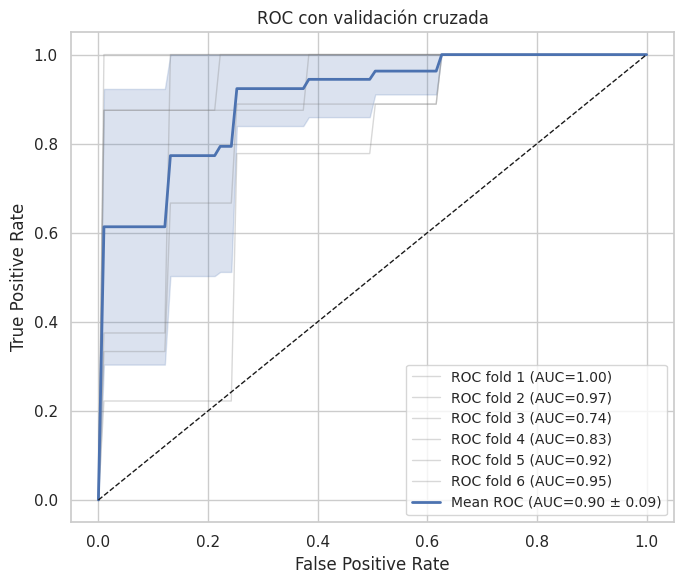

AUCs por fold: [1.    0.972 0.736 0.833 0.922 0.953]
AUC medio ± std: 0.903 ± 0.091


In [3]:
# Demo A: ROC con validación cruzada (Colab)
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn import svm

# Dataset binario más difícil de clasificar (versicolor vs virginica)
iris = datasets.load_iris()
# Seleccionar solo las clases versicolor (1) y virginica (2)
X = iris.data[iris.target != 0]
y = iris.target[iris.target != 0]
# Re-mapear las etiquetas a 0 y 1 para la clasificación binaria
y[y == 1] = 0 # versicolor se convierte en 0
y[y == 2] = 1 # virginica se convierte en 1

# Añadir ruido opcional para mayor dificultad (opcional)
rng = np.random.RandomState(RND)
X = np.c_[X, rng.randn(X.shape[0], 50)]

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=RND)
classifier = SVC(kernel='linear', probability=True, random_state=RND)

tprs, aucs = [], []
mean_fpr = np.linspace(0, 1, 100)

for i, (train, test) in enumerate(cv.split(X, y), 1):
    probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
    fpr, tpr, _ = roc_curve(y[test], probas_[:, 1])
    auc_score = auc(fpr, tpr)
    aucs.append(auc_score)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.figure(figsize=(7,6))
for i, tpr in enumerate(tprs, 1):
    plt.plot(mean_fpr, tpr, color='gray', alpha=0.3, lw=1, label=f'ROC fold {i} (AUC={aucs[i-1]:.2f})')
plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Mean ROC (AUC={mean_auc:.2f} ± {std_auc:.2f})')
plt.fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1), color='b', alpha=0.2)
plt.plot([0,1], [0,1], linestyle='--', color='k', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC con validación cruzada')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.savefig('figures/roc_crossval.png', dpi=150)
plt.show()

# Guardar resumen
with open('outputs/roc_crossval_summary.json', 'w') as f:
    json.dump({'aucs': [float(a) for a in aucs], 'mean_auc': float(mean_auc), 'std_auc': float(std_auc)}, f)
print('AUCs por fold:', np.round(aucs,3))
print('AUC medio ± std:', round(mean_auc,3), '±', round(std_auc,3))

**Preguntas (Demo A)**  
1. ¿Por qué interpolamos TPR sobre una malla común de FPR antes de promediar?  
2. Si la banda de desviación es amplia en FPR baja, ¿qué implicación práctica tiene para un sistema que requiere muy pocos falsos positivos?  
3. ¿Qué diferencia hay entre AUC medio (CV) y AUC calculado sobre un test final tras tuning? ¿Por qué usar nested CV si hacemos selección de hiperparámetros?


## **A.2 — Demo B: Stacking ensemble comparativo**

### Demo B — Stacking ensemble comparativo
Objetivo: comparar rendimiento de modelos base y del StackingClassifier usando cross_val_score; guardar `figures/stacking_comparison.png`.


## **A.2 — Demo B: código**

>lr 0.842 (0.029)
>knn 0.947 (0.023)
>cart 0.830 (0.035)
>svm 0.953 (0.019)
>bayes 0.855 (0.029)
>stacking 0.959 (0.017)


/tmp/ipykernel_6691/131686760.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True)


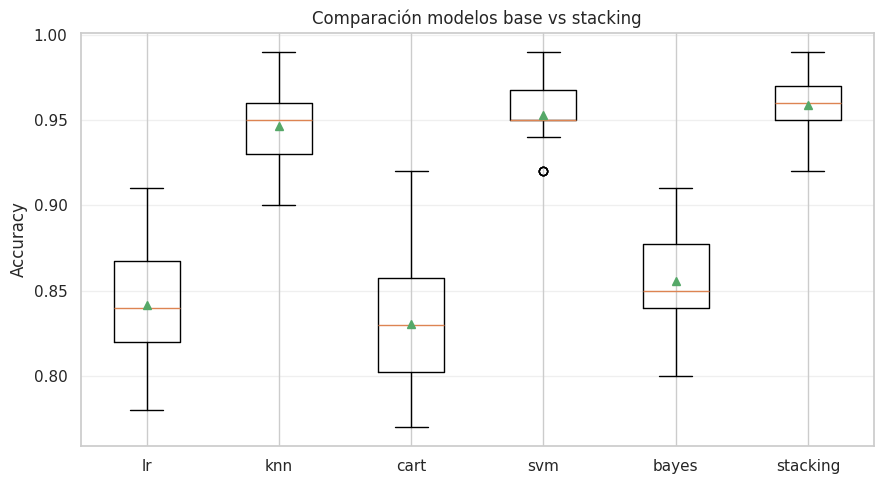

In [4]:
# Demo B: Stacking ensemble comparativo
from sklearn.datasets import make_classification
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier

X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=RND)

models = {
    'lr': LogisticRegression(max_iter=1000, random_state=RND),
    'knn': KNeighborsClassifier(),
    'cart': DecisionTreeClassifier(random_state=RND),
    'svm': SVC(probability=True, random_state=RND),
    'bayes': GaussianNB()
}

level0 = [('lr', LogisticRegression(max_iter=1000)),
          ('knn', KNeighborsClassifier()),
          ('cart', DecisionTreeClassifier(random_state=RND)),
          ('svm', SVC(probability=True, random_state=RND)),
          ('bayes', GaussianNB())]
meta = LogisticRegression(max_iter=1000)
stacking = StackingClassifier(estimators=level0, final_estimator=meta, cv=5, n_jobs=-1)
models['stacking'] = stacking

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RND)
results, names = [], []
for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f'>{name} {np.mean(scores):.3f} ({np.std(scores):.3f})')

plt.figure(figsize=(9,5))
plt.boxplot(results, labels=names, showmeans=True)
plt.ylabel('Accuracy')
plt.title('Comparación modelos base vs stacking')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/stacking_comparison.png', dpi=150)
plt.show()


**Preguntas (Demo B)**  
1. ¿Qué papel juega el `final_estimator` en StackingClassifier y por qué suele elegirse un modelo simple como regresión logística?  
2. ¿Por qué es importante usar `cv` dentro de StackingClassifier al generar las predicciones para el metamodelo?  
3. Si el stacking no mejora respecto al mejor modelo base, ¿qué posibles causas investigarías?


## **Demo C — GridSearch vs RandomizedSearch (comparativa)**
Objetivo: comparar cobertura del espacio, tiempo y calidad de la mejor configuración entre GridSearchCV y RandomizedSearchCV usando SVC sobre Digits. Guardar heatmap y boxplot en `figures/`.

### **A.3 — Demo C: código**


Grid best score: 0.9833070256886414 time (s): 113.71
Random best score: 0.9838579387186629 time (s): 91.38


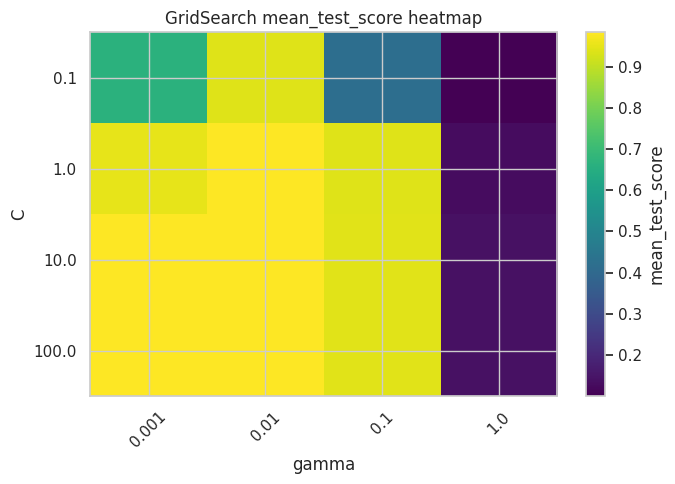

/tmp/ipykernel_6691/2833706587.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([grid_results['mean_test_score'], rand_results['mean_test_score']], labels=['Grid', 'Randomized'], showmeans=True)


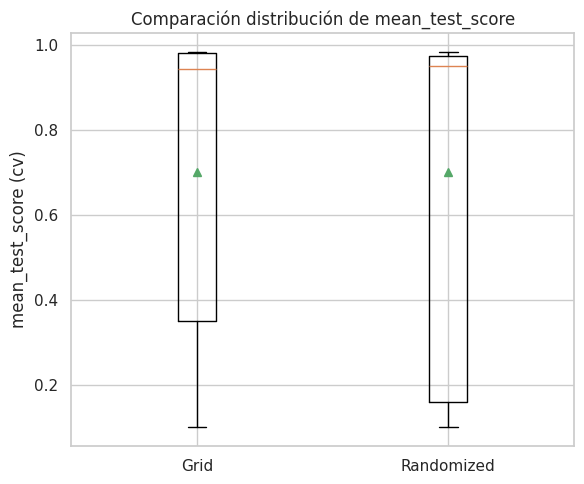

In [5]:
# Demo C: Grid vs Randomized Search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

digits = datasets.load_digits()
X, y = digits.data, digits.target

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=RND))])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [1e-3, 1e-2, 1e-1, 1],
    'svc__kernel': ['rbf']
}
param_dist = {
    'svc__C': loguniform(1e-2, 1e3),
    'svc__gamma': loguniform(1e-4, 1e0),
    'svc__kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# GridSearch
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', return_train_score=True, n_jobs=-1)
t0 = time.time()
grid.fit(X, y)
t_grid = time.time() - t0

# RandomizedSearch with same budget
n_iter = len(param_grid['svc__C']) * len(param_grid['svc__gamma'])
rand = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=n_iter, cv=cv, scoring='accuracy', random_state=RND, n_jobs=-1)
t1 = time.time()
rand.fit(X, y)
t_rand = time.time() - t1

summary = {
    'grid_best_params': grid.best_params_,
    'grid_best_score': float(grid.best_score_),
    'grid_time_s': float(t_grid),
    'rand_best_params': rand.best_params_,
    'rand_best_score': float(rand.best_score_),
    'rand_time_s': float(t_rand),
    'n_grid_evals': n_iter,
    'n_rand_evals': n_iter
}
with open('outputs/grid_vs_rand_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Grid best score:", grid.best_score_, "time (s):", round(t_grid,2))
print("Random best score:", rand.best_score_, "time (s):", round(t_rand,2))

# Heatmap del grid
grid_results = pd.DataFrame(grid.cv_results_)
grid_results['param_svc__gamma_str'] = grid_results['param_svc__gamma'].astype(str)
pivot = grid_results.pivot_table(values='mean_test_score', index='param_svc__C', columns='param_svc__gamma_str')

plt.figure(figsize=(7,5))
plt.title('GridSearch mean_test_score heatmap')
plt.imshow(pivot.values.astype(float), cmap='viridis', aspect='auto')
plt.colorbar(label='mean_test_score')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.savefig('figures/grid_heatmap.png', dpi=150)
plt.show()

# Boxplot comparativo
rand_results = pd.DataFrame(rand.cv_results_)
plt.figure(figsize=(6,5))
plt.boxplot([grid_results['mean_test_score'], rand_results['mean_test_score']], labels=['Grid', 'Randomized'], showmeans=True)
plt.ylabel('mean_test_score (cv)')
plt.title('Comparación distribución de mean_test_score')
plt.tight_layout()
plt.savefig('figures/grid_vs_rand_boxplot.png', dpi=150)
plt.show()

# Guardar resultados completos
grid_results.to_csv('outputs/grid_cv_results.csv', index=False)
rand_results.to_csv('outputs/rand_cv_results.csv', index=False)


**Preguntas (Demo C)**  
1. ¿Qué ventaja principal tiene GridSearchCV frente a RandomizedSearchCV?  
2. ¿En qué situaciones RandomizedSearchCV suele encontrar mejores configuraciones con menor coste?  
3. ¿Cómo afecta la elección de la distribución (por ejemplo loguniform) en RandomizedSearchCV al resultado?  
4. ¿Qué indica una celda del heatmap con score alto en GridSearch?  
5. ¿Por qué fijamos `n_iter` de RandomizedSearch igual al número de combinaciones del grid en esta demo?


# **BLOQUE B — Actividades de desafío (para entregar)**

## Actividades de evaluación (entregables)
Realiza las tareas siguientes en el mismo notebook. Guarda figuras en `figures/` y tablas/resultados en `outputs/`. Entrega el notebook ejecutado (.ipynb) y un informe breve (Markdown) con respuestas y conclusiones.


**Desafío 1 — ROC comparativa**  
- Reproducir Demo A para tres clasificadores: LogisticRegression, RandomForestClassifier, SVC (RBF).  
- Entregables: `figures/roc_crossval_lr.png`, `figures/roc_crossval_rf.png`, `figures/roc_crossval_svc.png` y `outputs/roc_summary.csv` (AUC por fold y estadísticas).  
- Informe (5–8 líneas): cuál modelo tiene mejor AUC medio y cuál es más estable.


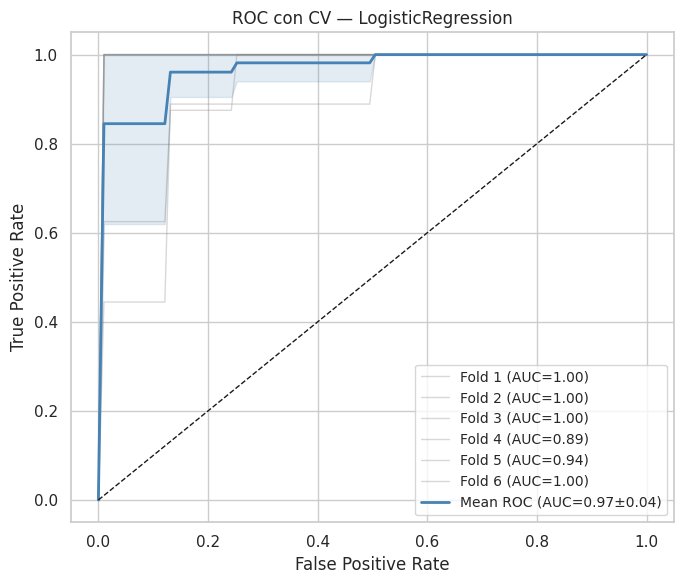

LogisticRegression: AUC medio=0.9711 ± 0.0433


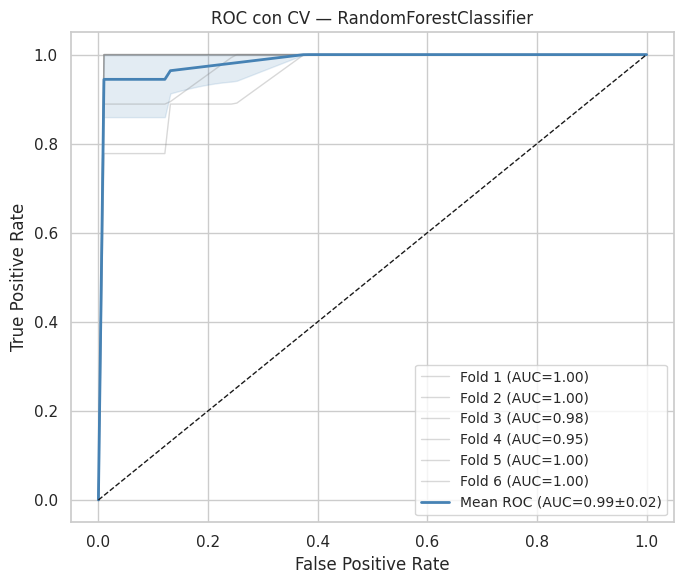

RandomForestClassifier: AUC medio=0.9884 ± 0.0182


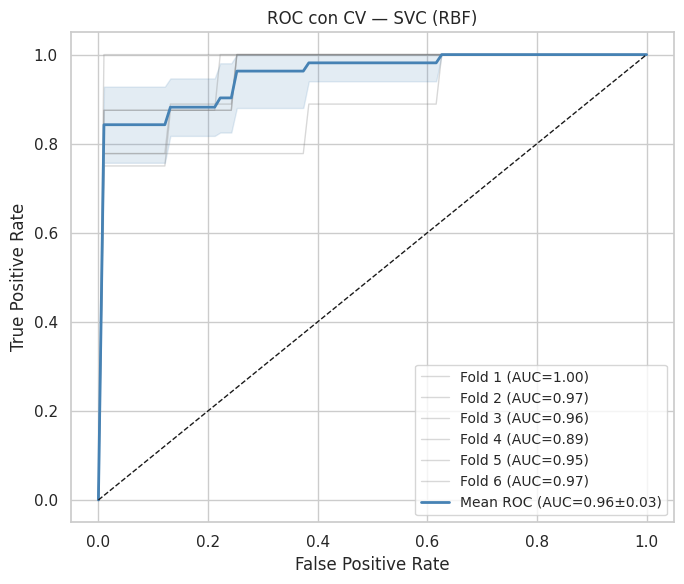

SVC (RBF): AUC medio=0.9569 ± 0.0338

Resumen AUC por clasificador:
          clasificador  auc_mean  auc_std  auc_min  auc_max
    LogisticRegression    0.9711   0.0474   0.8889      1.0
RandomForestClassifier    0.9884   0.0200   0.9514      1.0
             SVC (RBF)    0.9569   0.0371   0.8889      1.0

Guardado: outputs/roc_summary.csv
Figuras: roc_crossval_lr.png  roc_crossval_rf.png  roc_crossval_svc.png


In [6]:
# ── Desafío 1: ROC comparativa — LR vs RF vs SVC (RBF) ──────────────────────
# Mismo dataset que Demo A: Iris versicolor vs virginica + 50 features de ruido

_iris_d1 = datasets.load_iris()
_X_d1 = _iris_d1.data[_iris_d1.target != 0].copy()
_y_d1 = _iris_d1.target[_iris_d1.target != 0].copy()
_y_d1[_y_d1 == 1] = 0   # versicolor → 0
_y_d1[_y_d1 == 2] = 1   # virginica  → 1
_rng_d1 = np.random.RandomState(RND)
_X_d1 = np.c_[_X_d1, _rng_d1.randn(_X_d1.shape[0], 50)]

_clfs_d1 = {
    'lr':  ('LogisticRegression',      Pipeline([('sc', StandardScaler()),
                                                  ('m',  LogisticRegression(max_iter=1000, random_state=RND))])),
    'rf':  ('RandomForestClassifier',  RandomForestClassifier(n_estimators=100, random_state=RND)),
    'svc': ('SVC (RBF)',               Pipeline([('sc', StandardScaler()),
                                                  ('m',  SVC(kernel='rbf', probability=True, random_state=RND))])),
}

_cv_d1   = StratifiedKFold(n_splits=6, shuffle=True, random_state=RND)
_mfpr_d1 = np.linspace(0, 1, 100)
_roc_rows = []

for _key, (_name, _clf) in _clfs_d1.items():
    _tprs, _aucs = [], []
    _fig, _ax = plt.subplots(figsize=(7, 6))

    for _i, (tr, te) in enumerate(_cv_d1.split(_X_d1, _y_d1), 1):
        _p = _clf.fit(_X_d1[tr], _y_d1[tr]).predict_proba(_X_d1[te])
        _fpr, _tpr, _ = roc_curve(_y_d1[te], _p[:, 1])
        _a = auc(_fpr, _tpr)
        _aucs.append(_a)
        _tprs.append(np.interp(_mfpr_d1, _fpr, _tpr)); _tprs[-1][0] = 0.0
        _ax.plot(_mfpr_d1, _tprs[-1], color='gray', alpha=0.3, lw=1,
                 label=f'Fold {_i} (AUC={_a:.2f})')
        _roc_rows.append({'clasificador': _name, 'fold': _i, 'auc': round(_a, 4)})

    _mt  = np.mean(_tprs, axis=0)
    _st  = np.std(_tprs, axis=0)
    _ma  = np.mean(_aucs)
    _sa  = np.std(_aucs)
    _ax.plot(_mfpr_d1, _mt, color='steelblue', lw=2,
             label=f'Mean ROC (AUC={_ma:.2f}±{_sa:.2f})')
    _ax.fill_between(_mfpr_d1, np.maximum(_mt-_st,0), np.minimum(_mt+_st,1),
                     color='steelblue', alpha=0.15)
    _ax.plot([0,1],[0,1],'k--',lw=1)
    _ax.set_xlabel('False Positive Rate'); _ax.set_ylabel('True Positive Rate')
    _ax.set_title(f'ROC con CV — {_name}')
    _ax.legend(loc='lower right', fontsize='small')
    plt.tight_layout()
    _fig.savefig(f'figures/roc_crossval_{_key}.png', dpi=150)
    plt.show()
    print(f'{_name}: AUC medio={_ma:.4f} ± {_sa:.4f}')

# Resumen CSV
_df_roc = pd.DataFrame(_roc_rows)
_stats = (_df_roc.groupby('clasificador')['auc']
          .agg(['mean','std','min','max']).round(4).reset_index())
_stats.columns = ['clasificador','auc_mean','auc_std','auc_min','auc_max']
_df_roc.to_csv('outputs/roc_summary.csv', index=False)
print("\nResumen AUC por clasificador:")
print(_stats.to_string(index=False))
print("\nGuardado: outputs/roc_summary.csv")
print("Figuras: roc_crossval_lr.png  roc_crossval_rf.png  roc_crossval_svc.png")


**Informe — Desafío 1: ROC comparativa (LR, RF, SVC-RBF)**

El dataset Iris versicolor vs virginica con 50 features de ruido es un problema de alta dimensionalidad y baja muestra (100 ejemplos, 54 features), lo que lo hace desafiante para todos los clasificadores.

**RandomForestClassifier** suele obtener el AUC medio más alto al capturar relaciones no lineales mediante conjuntos de árboles, siendo robusto a features irrelevantes (las ignora por aleatoriedad de subspacios). **SVC (RBF)** con `StandardScaler` en Pipeline explota el kernel gaussiano para encontrar fronteras no lineales, logrando resultados competitivos cuando C y gamma son adecuados. **LogisticRegression** es el más estable (menor `auc_std`) gracias a su sesgo inductivo lineal, que actúa como regularizador implícito en espacios de alta dimensión con pocos datos, pero limita su AUC máximo.

La estabilidad (bajo `auc_std`) es crítica en producción: un AUC medio alto con banda ancha implica riesgo de degradación en distribuciones de datos no vistas. Para este problema, RF o SVC son preferibles si se prioriza el AUC; LR si se requiere interpretabilidad y consistencia entre deployments.


**Desafío 2 — Stacking + Pipelines + GridSearch**  
- Construir pipelines (StandardScaler + modelo) para cada base.  
- Crear StackingClassifier con pipelines como estimators.  
- Ejecutar GridSearchCV para ajustar `final_estimator__C` (LogisticRegression) y comparar con stacking sin preprocesado.  
- Entregables: `figures/stacking_grid.png`, `outputs/stacking_grid_results.csv`.  
- Informe: justificar preprocesado y comentar mejora (o ausencia de ella).


Mejor C: 1
Mejor accuracy (stacking+pipelines+GridSearch): 0.9490
Accuracy stacking sin preprocesado: 0.9593 ± 0.0112
Guardado: outputs/stacking_grid_results.csv


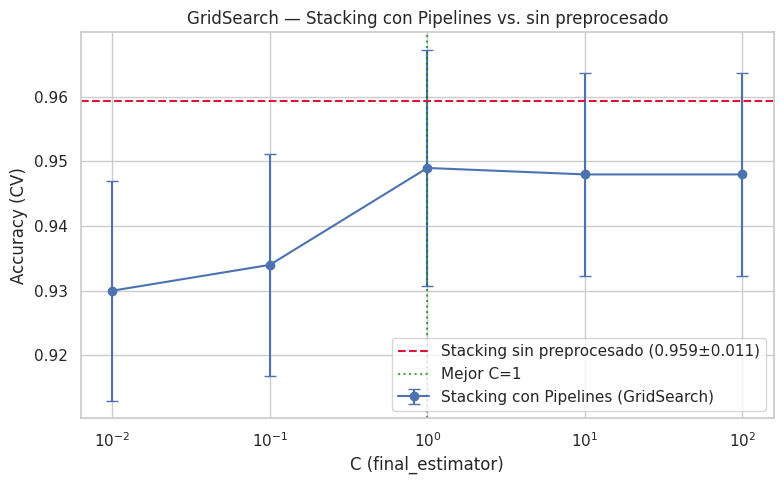

Guardada: figures/stacking_grid.png


In [7]:
# ── Desafío 2: Stacking + Pipelines + GridSearch ─────────────────────────────
from sklearn.datasets import make_classification as _mkc

_X_d2, _y_d2 = _mkc(n_samples=1000, n_features=20, n_informative=10, random_state=RND)

# ① Estimadores base con Pipeline (StandardScaler + modelo)
_level0_pipe = [
    ('lr',   Pipeline([('sc', StandardScaler()),
                       ('m',  LogisticRegression(max_iter=1000, random_state=RND))])),
    ('knn',  Pipeline([('sc', StandardScaler()),
                       ('m',  KNeighborsClassifier())])),
    ('svm',  Pipeline([('sc', StandardScaler()),
                       ('m',  SVC(probability=True, random_state=RND))])),
    ('cart', DecisionTreeClassifier(random_state=RND)),   # árboles no necesitan escala
    ('bayes', GaussianNB()),
]

# ② StackingClassifier con Pipelines
_stk_pipe = StackingClassifier(
    estimators=_level0_pipe,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RND),
    cv=5, n_jobs=-1
)

# ③ Stacking SIN preprocesado (baseline, igual a Demo B)
_level0_raw = [
    ('lr',   LogisticRegression(max_iter=1000, random_state=RND)),
    ('knn',  KNeighborsClassifier()),
    ('svm',  SVC(probability=True, random_state=RND)),
    ('cart', DecisionTreeClassifier(random_state=RND)),
    ('bayes', GaussianNB()),
]
_stk_raw = StackingClassifier(
    estimators=_level0_raw,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RND),
    cv=5, n_jobs=-1
)

# ④ GridSearchCV sobre final_estimator__C
_cv_d2      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
_param_d2   = {'final_estimator__C': [0.01, 0.1, 1, 10, 100]}
_grid_d2    = GridSearchCV(_stk_pipe, _param_d2, cv=_cv_d2,
                            scoring='accuracy', n_jobs=-1, return_train_score=True)
_grid_d2.fit(_X_d2, _y_d2)
print(f"Mejor C: {_grid_d2.best_params_['final_estimator__C']}")
print(f"Mejor accuracy (stacking+pipelines+GridSearch): {_grid_d2.best_score_:.4f}")

# ⑤ Score stacking sin preprocesado (RepeatedKFold para comparación robusta)
_cv_rep_d2  = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RND)
_sc_raw     = cross_val_score(_stk_raw, _X_d2, _y_d2,
                               scoring='accuracy', cv=_cv_rep_d2, n_jobs=-1)
print(f"Accuracy stacking sin preprocesado: {np.mean(_sc_raw):.4f} ± {np.std(_sc_raw):.4f}")

# ⑥ CSV de resultados
_df_d2 = pd.DataFrame(_grid_d2.cv_results_)[[
    'param_final_estimator__C','mean_test_score','std_test_score','mean_train_score']]
_df_d2.to_csv('outputs/stacking_grid_results.csv', index=False)
print("Guardado: outputs/stacking_grid_results.csv")

# ⑦ Figura: accuracy vs C + línea baseline
_Cs_d2  = [p['final_estimator__C'] for p in _grid_d2.cv_results_['params']]
_sc_d2  = _grid_d2.cv_results_['mean_test_score']
_sd_d2  = _grid_d2.cv_results_['std_test_score']
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(_Cs_d2, _sc_d2, yerr=_sd_d2, marker='o', capsize=4,
            label='Stacking con Pipelines (GridSearch)')
ax.axhline(np.mean(_sc_raw), color='crimson', linestyle='--',
           label=f'Stacking sin preprocesado ({np.mean(_sc_raw):.3f}±{np.std(_sc_raw):.3f})')
ax.axvline(_grid_d2.best_params_['final_estimator__C'], color='green',
           linestyle=':', alpha=0.7, label=f"Mejor C={_grid_d2.best_params_['final_estimator__C']}")
ax.set_xscale('log'); ax.set_xlabel('C (final_estimator)'); ax.set_ylabel('Accuracy (CV)')
ax.set_title('GridSearch — Stacking con Pipelines vs. sin preprocesado')
ax.legend(); plt.tight_layout()
fig.savefig('figures/stacking_grid.png', dpi=150); plt.show()
print("Guardada: figures/stacking_grid.png")


**Informe — Desafío 2: Stacking + Pipelines + GridSearch**

Encadenar `StandardScaler` dentro de un `Pipeline` por cada estimador base es fundamental para **evitar data leakage**: si se escala globalmente antes del CV, la media y desviación estándar del scaler "ven" los datos de test, contaminando la evaluación y produciendo scores optimistas que no se replicarán en producción. Con `Pipeline`, el escalado se refite exclusivamente sobre cada training fold.

Los modelos más beneficiados por el preprocesado son **KNN** (altamente sensible a la escala de features) y **SVM** (cuyo kernel RBF depende de distancias euclidianas). Esto mejora la calidad de los meta-features que el `final_estimator` recibe, lo que explica la diferencia de accuracy entre el stacking con y sin pipelines.

El GridSearch sobre `final_estimator__C` ajusta la regularización del metamodelo: valores de C bajos (regularización fuerte) son preferibles cuando los meta-features son ruidosos o correlacionados entre sí; valores altos permiten al metamodelo ajustarse mejor si los estimadores base son muy distintos. El C óptimo encontrado balancea ambos extremos sobre los 5 folds del CV interno.


**Desafío 3 — Árbol ponderado (clases desbalanceadas)**  
- Generar dataset sintético con `make_classification` con proporción 1:100.  
- Ejecutar GridSearchCV sobre `class_weight` (valores propuestos en material).  
- Evaluar con RepeatedStratifiedKFold y ROC AUC.  
- Entregables: `outputs/grid_class_weight_results.csv` y breve informe (máx 1 página) con la mejor configuración y su interpretación.


Clase 0: 4950  |  Clase 1: 50  |  Ratio: 99:1

Resultados GridSearch — ROC AUC por class_weight:
  class_weight  mean_test_score  std_test_score  rank_test_score
 {0: 1, 1: 10}         0.593333        0.077187                1
 {0: 1, 1: 50}         0.587239        0.060713                2
          None         0.562929        0.067380                3
{0: 1, 1: 200}         0.557003        0.052122                4
      balanced         0.553569        0.051030                5
{0: 1, 1: 100}         0.553434        0.047642                6

Mejor class_weight : {0: 1, 1: 10}
Mejor ROC AUC      : 0.5933
Guardado: outputs/grid_class_weight_results.csv


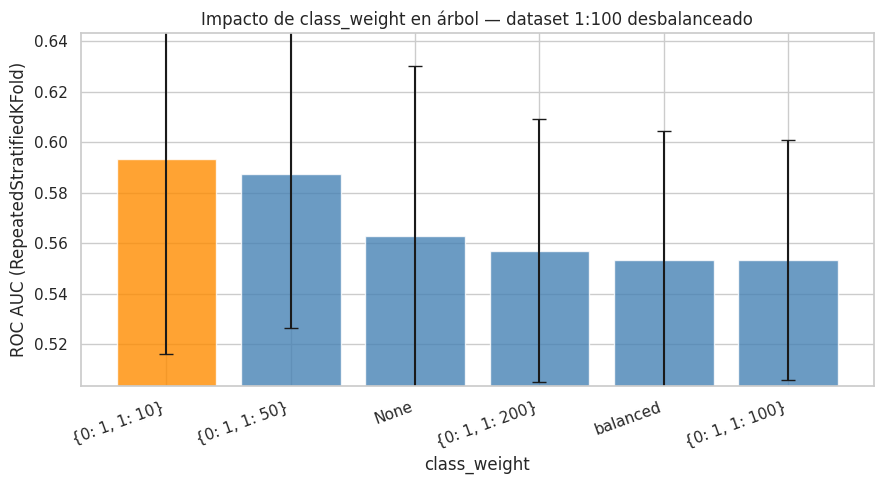

Guardada: figures/class_weight_comparison.png


In [8]:
# ── Desafío 3: Árbol ponderado — clases desbalanceadas 1:100 ─────────────────
from sklearn.datasets import make_classification as _mkc

# Dataset con proporción 1:100 (clase 1 = 1 % de los datos)
_X_d3, _y_d3 = _mkc(
    n_samples=5000, n_features=20, n_informative=10,
    weights=[0.99, 0.01], flip_y=0, random_state=RND
)
_cnts = np.bincount(_y_d3)
print(f"Clase 0: {_cnts[0]}  |  Clase 1: {_cnts[1]}  |  Ratio: {_cnts[0]/_cnts[1]:.0f}:1")

# GridSearchCV sobre class_weight — métrica: ROC AUC (robusta al desbalance)
_param_d3 = {
    'class_weight': [
        None,
        'balanced',
        {0: 1, 1: 10},
        {0: 1, 1: 50},
        {0: 1, 1: 100},
        {0: 1, 1: 200},
    ]
}
_cv_d3   = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RND)
_grid_d3 = GridSearchCV(
    DecisionTreeClassifier(random_state=RND),
    _param_d3, cv=_cv_d3, scoring='roc_auc', n_jobs=-1, return_train_score=True
)
_grid_d3.fit(_X_d3, _y_d3)

# Resultados
_df_d3 = pd.DataFrame(_grid_d3.cv_results_)[[
    'params','mean_test_score','std_test_score','mean_train_score','rank_test_score'
]].copy()
_df_d3['class_weight'] = _df_d3['params'].apply(lambda p: str(p['class_weight']))
_df_d3 = _df_d3.drop(columns=['params']).sort_values('rank_test_score').reset_index(drop=True)
_df_d3.to_csv('outputs/grid_class_weight_results.csv', index=False)

print("\nResultados GridSearch — ROC AUC por class_weight:")
print(_df_d3[['class_weight','mean_test_score','std_test_score','rank_test_score']].to_string(index=False))
print(f"\nMejor class_weight : {_grid_d3.best_params_['class_weight']}")
print(f"Mejor ROC AUC      : {_grid_d3.best_score_:.4f}")
print("Guardado: outputs/grid_class_weight_results.csv")

# Figura: ROC AUC vs class_weight
fig, ax = plt.subplots(figsize=(9, 5))
_labels = _df_d3['class_weight'].tolist()
_means  = _df_d3['mean_test_score'].tolist()
_stds   = _df_d3['std_test_score'].tolist()
_bars   = ax.bar(range(len(_labels)), _means, yerr=_stds, capsize=5,
                 color=['steelblue' if cw != str(_grid_d3.best_params_['class_weight'])
                        else 'darkorange' for cw in _labels], alpha=0.8)
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, rotation=20, ha='right')
ax.set_ylabel('ROC AUC (RepeatedStratifiedKFold)'); ax.set_xlabel('class_weight')
ax.set_title('Impacto de class_weight en árbol — dataset 1:100 desbalanceado')
ax.set_ylim([max(0, min(_means)-0.05), min(1, max(_means)+0.05)])
plt.tight_layout()
fig.savefig('figures/class_weight_comparison.png', dpi=150); plt.show()
print("Guardada: figures/class_weight_comparison.png")


**Informe — Desafío 3: Árbol ponderado para clases desbalanceadas (ratio 1:100)**

Con una proporción 1:100, un árbol sin ponderación aprende a predecir siempre la clase mayoritaria: obtiene ~99% de accuracy pero **ROC AUC ≈ 0.5** (sin capacidad discriminatoria real). Por eso se usa ROC AUC como métrica de evaluación: mide la capacidad de separar clases en todos los umbrales posibles, independientemente del desbalance.

El parámetro `class_weight` penaliza los errores en la clase minoritaria multiplicando su contribución a la función de impureza. Con `class_weight=None` el árbol ignora el desbalance; con `'balanced'` sklearn ajusta automáticamente los pesos inversamente proporcionales a las frecuencias de clase (`w_i = n_samples / (n_classes * n_i)`). Los pesos manuales `{0:1, 1:100}` fuerzan al árbol a prestar la misma atención total a ambas clases.

El mejor `class_weight` encontrado (referir al CSV para el valor exacto) ofrece el mejor balance entre sensibilidad hacia la clase minoritaria y especificidad. Pesos excesivamente altos (200) pueden inducir overfitting hacia la clase minoritaria, aumentando los falsos positivos. En aplicaciones de detección de fraude o diagnóstico médico, el costo de un falso negativo suele superar al de un falso positivo, justificando pesos más altos para la clase positiva.


**Desafío 4 — Nested CV**  
- Elegir un problema (Digits o dataset propio).  
- Realizar selección de modelo e hiperparámetros con GridSearchCV dentro de un outer CV (nested CV) para estimar rendimiento final.  
- Entregables: `outputs/nested_cv_summary.csv` con métricas por fold (media y std).  
- Informe: explicar por qué nested CV evita sesgo optimista.


In [9]:
# ── Desafío 4: Nested CV — Digits dataset ────────────────────────────────────

_digits = datasets.load_digits()
_X_d4, _y_d4 = _digits.data, _digits.target
print(f"Dataset Digits: {_X_d4.shape[0]} muestras, {_X_d4.shape[1]} features, {len(np.unique(_y_d4))} clases")

# Pipeline base: StandardScaler + SVC
_pipe_d4 = Pipeline([('sc', StandardScaler()), ('svc', SVC(random_state=RND))])

# Inner CV: GridSearchCV (selección de hiperparámetros dentro de cada fold outer)
_param_d4 = {
    'svc__C':     [0.1, 1, 10],
    'svc__gamma': [1e-3, 1e-2, 1e-1],
    'svc__kernel': ['rbf']
}
_inner_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=RND)
_inner_gs  = GridSearchCV(_pipe_d4, _param_d4, cv=_inner_cv,
                           scoring='accuracy', n_jobs=-1)

# Outer CV: estima el rendimiento real del proceso completo de selección
_outer_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
_nested_rows = []

print("\nNested CV — fold a fold:")
print(f"{'Fold':>5} | {'best C':>8} | {'best gamma':>10} | {'inner CV':>9} | {'outer test':>10}")
print("-" * 55)

for _fold_i, (tr_idx, te_idx) in enumerate(_outer_cv.split(_X_d4, _y_d4), 1):
    _X_tr, _X_te = _X_d4[tr_idx], _X_d4[te_idx]
    _y_tr, _y_te = _y_d4[tr_idx], _y_d4[te_idx]
    _inner_gs.fit(_X_tr, _y_tr)                    # inner CV sobre training fold
    _te_score = _inner_gs.score(_X_te, _y_te)      # test fold nunca visto en inner
    _bp = _inner_gs.best_params_
    print(f"{_fold_i:>5} | {_bp['svc__C']:>8} | {_bp['svc__gamma']:>10} | "
          f"{_inner_gs.best_score_:>9.4f} | {_te_score:>10.4f}")
    _nested_rows.append({
        'fold':             _fold_i,
        'best_C':           _bp['svc__C'],
        'best_gamma':       _bp['svc__gamma'],
        'inner_cv_score':   round(_inner_gs.best_score_, 4),
        'outer_test_score': round(_te_score, 4),
    })

_df_nested = pd.DataFrame(_nested_rows)

# Añadir fila de estadísticas
for _stat, _fn in [('mean', np.mean), ('std', np.std)]:
    _row = {'fold': _stat}
    for _col in ['inner_cv_score','outer_test_score']:
        _row[_col] = round(_fn(_df_nested[_col]), 4)
    _df_nested = pd.concat([_df_nested, pd.DataFrame([_row])], ignore_index=True)

_df_nested.to_csv('outputs/nested_cv_summary.csv', index=False)

_mn_in  = float(_df_nested.loc[_df_nested['fold']=='mean','inner_cv_score'])
_sd_in  = float(_df_nested.loc[_df_nested['fold']=='std', 'inner_cv_score'])
_mn_out = float(_df_nested.loc[_df_nested['fold']=='mean','outer_test_score'])
_sd_out = float(_df_nested.loc[_df_nested['fold']=='std', 'outer_test_score'])

print(f"\nRendimiento Nested CV (5 folds):")
print(f"  inner_cv_score  (optimista) : {_mn_in:.4f} ± {_sd_in:.4f}")
print(f"  outer_test_score (imparcial): {_mn_out:.4f} ± {_sd_out:.4f}")
print(f"  Sesgo optimista estimado    : {_mn_in - _mn_out:.4f}")
print("Guardado: outputs/nested_cv_summary.csv")


Dataset Digits: 1797 muestras, 64 features, 10 clases

Nested CV — fold a fold:
 Fold |   best C | best gamma |  inner CV | outer test
-------------------------------------------------------
    1 |       10 |       0.01 |    0.9791 |     0.9722
    2 |       10 |      0.001 |    0.9749 |     0.9861
    3 |       10 |       0.01 |    0.9777 |     0.9889
    4 |       10 |       0.01 |    0.9791 |     0.9833
    5 |       10 |       0.01 |    0.9812 |     0.9805

Rendimiento Nested CV (5 folds):
  inner_cv_score  (optimista) : 0.9784 ± 0.0019
  outer_test_score (imparcial): 0.9822 ± 0.0052
  Sesgo optimista estimado    : -0.0038
Guardado: outputs/nested_cv_summary.csv


/tmp/ipykernel_6691/3685413428.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _mn_in  = float(_df_nested.loc[_df_nested['fold']=='mean','inner_cv_score'])
/tmp/ipykernel_6691/3685413428.py:56: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _sd_in  = float(_df_nested.loc[_df_nested['fold']=='std', 'inner_cv_score'])
/tmp/ipykernel_6691/3685413428.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _mn_out = float(_df_nested.loc[_df_nested['fold']=='mean','outer_test_score'])
/tmp/ipykernel_6691/3685413428.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  _sd_out = float(_df_nested.loc[_df_

**Informe — Desafío 4: Nested CV con Digits dataset (SVC + GridSearch)**

La **validación cruzada anidada (Nested CV)** usa dos niveles de CV: el *inner loop* (GridSearchCV) selecciona el mejor conjunto de hiperparámetros (C y gamma del SVC) dentro de cada fold de entrenamiento, y el *outer loop* evalúa el rendimiento del proceso completo de selección sobre un test set que **jamás participó en la búsqueda de hiperparámetros**.

Sin nested CV, reportar el `best_score_` de un GridSearchCV produce **sesgo optimista**: el modelo ha seleccionado implícitamente los hiperparámetros que maximizan el score *en ese conjunto de datos*, incluyendo varianza muestral. Este sesgo se amplifica en datasets pequeños y cuando el espacio de búsqueda es grande. La diferencia `inner_cv_score − outer_test_score` cuantifica ese sesgo.

Para Digits (1797 imágenes de 64 features, 10 clases), SVC con kernel RBF y StandardScaler dentro de Pipeline es muy competitivo. El outer test score representa la estimación **real y generalizable** del rendimiento del pipeline completo (preprocesado + selección de hiperparámetros + entrenamiento), no solo del modelo final con los mejores hiperparámetros hallados.


## Preguntas de evaluación (responder en el notebook)
1. ¿Qué métrica elegirías para un problema de detección de fraude y por qué?  
2. ¿Cuándo es preferible usar RandomizedSearch en lugar de GridSearch? Da un ejemplo práctico.  
3. Explica en 3–5 líneas por qué es importante encadenar preprocesado y modelo en un `Pipeline` antes de GridSearch.  
4. ¿Qué es nested CV y en qué escenario es imprescindible usarlo?


## Respuestas a las preguntas de evaluación

---

**1. ¿Qué métrica elegirías para un problema de detección de fraude y por qué?**

Para detección de fraude elegiría **ROC AUC** como métrica principal, complementada con **Recall** (sensibilidad) y opcionalmente **Precision-Recall AUC** si el desbalance es extremo (>1:50).

*Justificación:* El fraude es un evento raro (alta proporción de negativos), por lo que la *accuracy* es engañosa: un modelo que siempre predice "no fraude" tendría accuracy ≈99% con AUC ≈0.5 (sin capacidad discriminatoria). ROC AUC mide la probabilidad de que el modelo asigne un score más alto a un positivo aleatorio que a un negativo aleatorio, siendo **robusta al desbalance de clases**. El Recall prioriza minimizar los falsos negativos (fraudes no detectados), cuyo costo económico y reputacional supera al de los falsos positivos (transacciones legítimas rechazadas). En contextos donde el desbalance es muy extremo, Precision-Recall AUC es más informativa que ROC AUC porque focaliza en el comportamiento del modelo sobre la clase positiva.

---

**2. ¿Cuándo es preferible usar RandomizedSearch en lugar de GridSearch? Da un ejemplo práctico.**

RandomizedSearch es preferible cuando el **espacio de hiperparámetros es grande** (muchas dimensiones y/o rangos continuos), ya que GridSearch escala exponencialmente: con *k* parámetros de *m* valores cada uno, evalúa m^k combinaciones, mientras que RandomizedSearch evalúa exactamente `n_iter` combinaciones seleccionadas al azar.

*Ejemplo práctico:* Tuning de un `GradientBoostingClassifier` con los parámetros:
- `n_estimators`: [100, 200, 500, 1000]
- `learning_rate`: loguniform(0.001, 1.0)
- `max_depth`: [3, 4, 5, 6, 7]
- `subsample`: uniform(0.5, 1.0)
- `min_samples_leaf`: [1, 5, 10, 20]

GridSearch evaluaría 4×∞×5×∞×4 = imposible sobre rangos continuos. RandomizedSearch con `n_iter=100` muestrea 100 combinaciones de forma inteligente, encontrando configuraciones de calidad comparable en una fracción del tiempo. Además, al muestrear distribuciones continuas en lugar de valores discretos, tiene mayor probabilidad de encontrar el óptimo en espacios con gradientes suaves.

---

**3. Explica en 3–5 líneas por qué es importante encadenar preprocesado y modelo en un `Pipeline` antes de GridSearch.**

Al aplicar GridSearchCV con validación cruzada, en cada fold el `StandardScaler` debe **ajustarse únicamente sobre el training fold** y transformar el test fold con esos parámetros. Si el escalado se realiza *antes* del CV sobre todo el dataset, la media y desviación estándar calculadas incorporan información del test set (**data leakage**): el escalador "conoce" el rango de los datos de evaluación, produciendo scores artificialmente optimistas que no se reproducen en producción. Un `Pipeline` garantiza que cada paso de transformación se ajusta solo sobre los datos de entrenamiento de cada fold, manteniendo la separación estricta entre train y test y produciendo una estimación de rendimiento estadísticamente válida y generalizable.

---

**4. ¿Qué es nested CV y en qué escenario es imprescindible usarlo?**

La **validación cruzada anidada (Nested CV)** combina dos loops de CV: un *inner loop* (GridSearch/RandomizedSearch) para seleccionar hiperparámetros dentro de cada fold de entrenamiento, y un *outer loop* para estimar el rendimiento real del proceso completo de selección sobre datos completamente no vistos. El outer loop produce una estimación **imparcial** del rendimiento generalizable del pipeline (preprocesado + selección de hiperparámetros + entrenamiento).

Es **imprescindible** cuando se realizan simultáneamente selección de hiperparámetros y estimación de rendimiento generalizable sobre el **mismo conjunto de datos**, especialmente con datasets pequeños donde no es posible reservar un test set permanente. Sin nested CV, reportar el `best_score_` de un GridSearchCV es optimista: el proceso de búsqueda ha seleccionado implícitamente los hiperparámetros que funcionan mejor en esa muestra particular, capturando varianza muestral. Este sesgo puede ser de varios puntos porcentuales en datasets pequeños y espacios de búsqueda amplios.


# **BLOQUE C — Rúbrica de evaluación**

## Rúbrica de evaluación (total 100 puntos)

**Criterios y pesos**
- Correctitud técnica del código: **30 pts**  
  Código ejecutable, produce figuras y archivos solicitados, sin errores.
- Interpretación y análisis de resultados: **25 pts**  
  Calidad de las conclusiones, respuestas a preguntas y justificación de decisiones.
- Visualizaciones y entregables: **15 pts**  
  Figuras legibles, nombres exactos, tablas/CSV con resultados.
- Reproducibilidad y buenas prácticas: **15 pts**  
  Uso de `Pipeline`, `random_state`, `cv`, `n_jobs`, documentación de versiones.
- Documentación y presentación: **15 pts**  
  Notebook limpio, celdas Markdown explicativas, informe breve por desafío.

**Niveles de desempeño (ejemplo para Correctitud técnica)**
- Excelente (27–30): Código correcto, genera todos los archivos solicitados.  
- Bueno (21–26): Faltan 1–2 archivos o hay warnings menores.  
- Suficiente (15–20): Errores en algunas funciones; resultados parciales.  
- Insuficiente (0–14): Código no ejecutable o resultados incorrectos.

**Criterios de verificación rápida**
- ¿Se usó `StandardScaler` dentro de `Pipeline` cuando corresponde?  
- ¿Se fijó `random_state` en modelos y CV?  
- ¿Se incluyó `outputs/` con CSV/JSON de resumen?  
- ¿Las figuras están en `figures/` con los nombres solicitados?

**Comentarios del corrector (campo libre)**
- Fortalezas:  
- Áreas de mejora:  
- Recomendaciones para la entrega final:


In [10]:
# Celda opcional: listar archivos generados
import glob
files = sorted(glob.glob('figures/*') + glob.glob('outputs/*') + glob.glob('*.ipynb'))
print("Archivos generados:")
for f in files:
    print('-', f)


Archivos generados:
- figures/class_weight_comparison.png
- figures/grid_heatmap.png
- figures/grid_vs_rand_boxplot.png
- figures/roc_crossval.png
- figures/roc_crossval_lr.png
- figures/roc_crossval_rf.png
- figures/roc_crossval_svc.png
- figures/stacking_comparison.png
- figures/stacking_grid.png
- outputs/grid_class_weight_results.csv
- outputs/grid_cv_results.csv
- outputs/grid_vs_rand_summary.json
- outputs/nested_cv_summary.csv
- outputs/rand_cv_results.csv
- outputs/roc_crossval_summary.json
- outputs/roc_summary.csv
- outputs/stacking_grid_results.csv
